In [ ]:
!pip install networkx
!pip install matplotlib
!pip install ipywidgets

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import tracemalloc
import ipywidgets as widgets
from IPython.display import display
import time

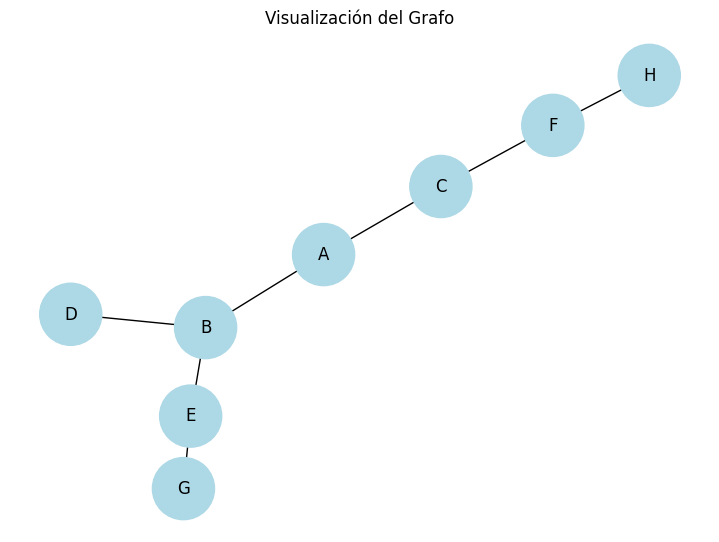

In [ ]:
# Crear grafo
G = nx.Graph()

edges = [
    ("A","B"),
    ("A","C"),
    ("B","D"),
    ("B","E"),
    ("C","F"),
    ("E","G"),
    ("F","H"),
]

G.add_edges_from(edges)

def dibujar_grafo(resaltados=None):

    pos = nx.spring_layout(G)

    colores = []
    for nodo in G.nodes():
        if resaltados and nodo in resaltados:
            colores.append("orange")
        else:
            colores.append("lightblue")

    plt.figure(figsize=(7,5))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=colores,
        node_size=2000,
        font_size=12
    )

    plt.title("Visualización del Grafo")
    plt.show()

dibujar_grafo()

In [ ]:
def bfs(grafo, inicio, objetivo, visualizar=False):

    cola = deque([[inicio]])
    visitados = set()

    pasos = []

    while cola:

        camino = cola.popleft()
        nodo = camino[-1]

        pasos.append(nodo)

        if nodo == objetivo:
            return camino, pasos

        if nodo not in visitados:
            visitados.add(nodo)

            for vecino in grafo.neighbors(nodo):

                nuevo_camino = list(camino)
                nuevo_camino.append(vecino)

                cola.append(nuevo_camino)

    return None, pasos

In [ ]:
def dfs(grafo, inicio, objetivo):

    pila = [[inicio]]
    visitados = set()

    pasos = []

    while pila:

        camino = pila.pop()
        nodo = camino[-1]

        pasos.append(nodo)

        if nodo == objetivo:
            return camino, pasos

        if nodo not in visitados:

            visitados.add(nodo)

            for vecino in grafo.neighbors(nodo):

                nuevo_camino = list(camino)
                nuevo_camino.append(vecino)

                pila.append(nuevo_camino)

    return None, pasos

In [ ]:
def medir_memoria(funcion, grafo, inicio, objetivo):

    tracemalloc.start()

    resultado = funcion(grafo, inicio, objetivo)

    memoria = tracemalloc.get_traced_memory()[1]

    tracemalloc.stop()

    return resultado, memoria

In [ ]:
inicio_selector = widgets.Dropdown(
    options=list(G.nodes()),
    description="Inicio:"
)

objetivo_selector = widgets.Dropdown(
    options=list(G.nodes()),
    description="Objetivo:"
)

boton = widgets.Button(
    description="Ejecutar análisis",
    button_style="success"
)

In [ ]:
def ejecutar_algoritmos(b):

    inicio = inicio_selector.value
    objetivo = objetivo_selector.value

    print("Nodo inicio:", inicio)
    print("Nodo objetivo:", objetivo)

    print("\n--- BFS ---")

    (camino_bfs, pasos_bfs), mem_bfs = medir_memoria(bfs, G, inicio, objetivo)

    print("Camino BFS:", camino_bfs)
    print("Memoria usada:", mem_bfs, "bytes")

    print("\n--- DFS ---")

    (camino_dfs, pasos_dfs), mem_dfs = medir_memoria(dfs, G, inicio, objetivo)

    print("Camino DFS:", camino_dfs)
    print("Memoria usada:", mem_dfs, "bytes")

    print("\nVisualización BFS")
    dibujar_grafo(camino_bfs)

    print("Visualización DFS")
    dibujar_grafo(camino_dfs)

    # Comparación gráfica

    algoritmos = ["BFS","DFS"]
    memoria = [mem_bfs, mem_dfs]

    plt.figure(figsize=(6,4))

    plt.bar(algoritmos, memoria)

    plt.title("Comparación de memoria")
    plt.ylabel("Bytes usados")

    plt.show()

boton.on_click(ejecutar_algoritmos)

Dropdown(description='Inicio:', options=('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'), value='A')

Dropdown(description='Objetivo:', options=('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'), value='A')

Button(button_style='success', description='Ejecutar análisis', style=ButtonStyle())

Nodo inicio: H
Nodo objetivo: G

--- BFS ---
Camino BFS: ['H', 'F', 'C', 'A', 'B', 'E', 'G']
Memoria usada: 2304 bytes

--- DFS ---
Camino DFS: ['H', 'F', 'C', 'A', 'B', 'E', 'G']
Memoria usada: 1688 bytes

Visualización BFS


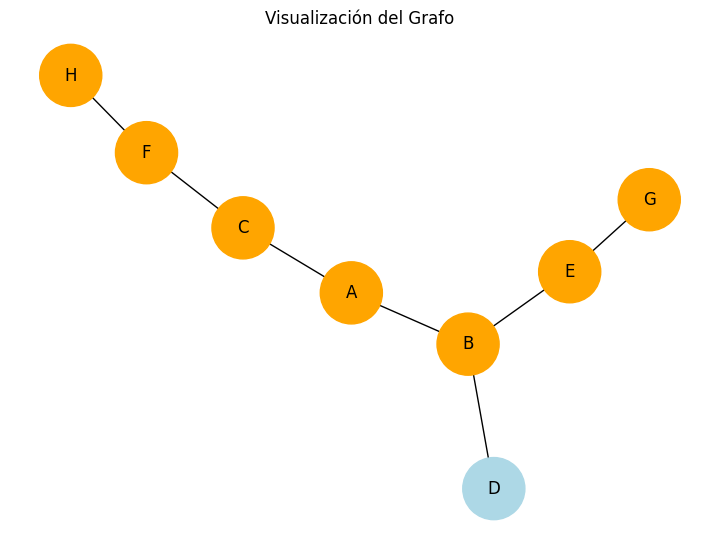

Visualización DFS


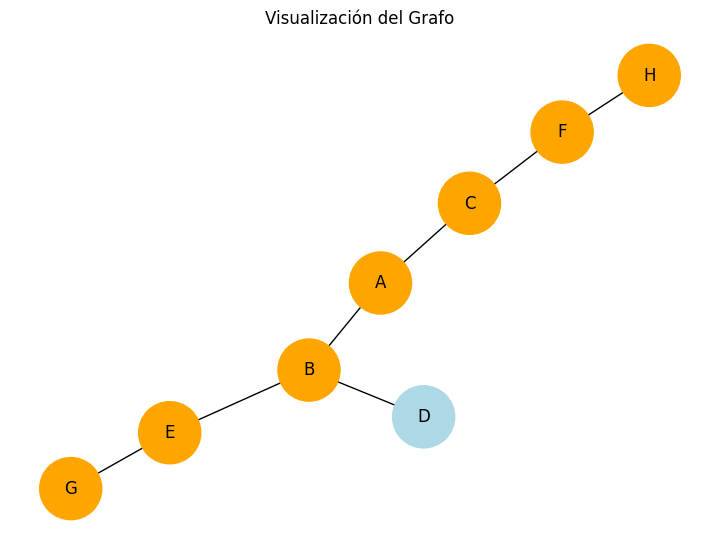

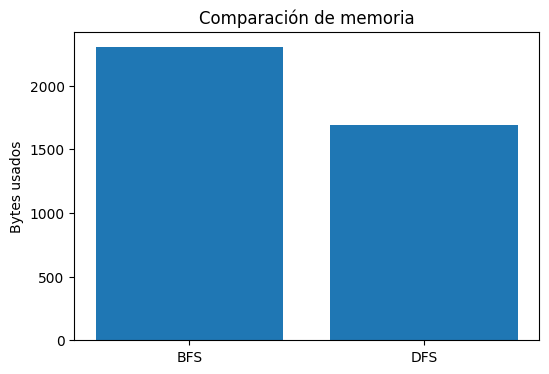

In [ ]:
display(inicio_selector)
display(objetivo_selector)
display(boton)